# Experiment Report — Event-Driven AI Financial Advisor

Tracks every training + backtest run logged in `data/4_experiments/experiment_log.csv`,
using a two-tier evaluation approach, fixed before the first run and kept
consistent across every later change so results stay comparable:

- **Tier 1** (`accuracy`, `precision`) — fast per-step sanity check on model quality
- **Tier 2** (`total_return`, `win_rate`, `max_drawdown`, `sharpe`) — the true
  cross-step gate, computed from actual backtested trade outcomes

Re-run this notebook after every new run is logged. Fill in the **Stage** sections
at the bottom as each experiment step is completed — that narrative is what
goes into the report's Evaluation chapter.


In [1]:
import sys, os

# Jupyter's cwd is this notebook's own folder, not the project root - chdir
# so the data/ and src/ relative paths used throughout the codebase resolve
# the same way here as they do when a script is run from the project root.
PROJECT_ROOT = os.path.abspath("..")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
from src.utils import experiment_log, experiment_charts as ec

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 140)


## All runs

Full log, with `config_json` expanded into its own columns. Runs are labeled
`Run 1, Run 2, ...` in chronological order rather than shown by `run_id` -
`run_id` embeds the real timestamp each run was created at (see
`experiment_log.new_run_id`), which isn't something the report needs to show.


In [2]:
log_df = experiment_log.load_experiment_log()
ec.report_table(log_df)


,Run_Label,config_json,accuracy,precision,total_return,win_rate,max_drawdown,sharpe,train_accuracy,train_precision,...,config_reg_lambda,config_scale_pos_weight,config_max_depth,config_min_child_weight,config_subsample,config_colsample_bytree,config_n_estimators,config_early_stopping_rounds,config_return_col,config_n_seeds
0,Run 1,{},0.568204,0.529769,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Run 2,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Run 3,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875}",0.563360,0.521202,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Run 4,{},0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Run 5,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,5.948502,0.528691,-0.426243,1.995847,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Run 6,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875}",0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Run 7,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""max_position_weight"": null}",0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Run 8,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""max_position_weight"": 0.2}",0.563360,0.521202,0.056162,0.499794,-0.436418,0.263148,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Run 9,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""max_position_weight"": 0.1}",0.563360,0.521202,0.014998,0.499794,-0.271251,0.152880,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Run 10,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.05, ""max_position_weight"": 0.2}",0.813938,0.336634,0.096135,0.534653,-0.129952,0.764668,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## What changed between runs

For each run after the first: which config key(s) changed vs. the immediately
preceding run, and how much each metric moved as a result. This is the
"what changed → what happened" record for the report — no need to
hand-track it separately.


In [3]:
diff_df = ec.diff_config_between_runs(log_df)
diff_df


,run_label,prev_run_label,config_changed,accuracy_delta,precision_delta,total_return_delta,win_rate_delta,max_drawdown_delta,sharpe_delta
0,Run 2,Run 1,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",0.006809,-0.008170,NaN,NaN,NaN,NaN
1,Run 3,Run 2,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",-0.011654,-0.000397,NaN,NaN,NaN,NaN
2,Run 4,Run 3,"{'universe': ('all_incl_delisted', nan), 'n_rows': (51875.0, nan), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",0.000000,0.000000,NaN,NaN,NaN,NaN
3,Run 5,Run 4,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",0.011654,0.000397,6.055801,0.028897,0.341420,1.617441
4,Run 6,Run 5,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",-0.011654,-0.000397,-6.055801,-0.028897,-0.341420,-1.617441
5,Run 7,Run 6,"{'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'c

## Tier 1 — model-quality trend

Valid only *within* a step where the label definition hasn't changed.

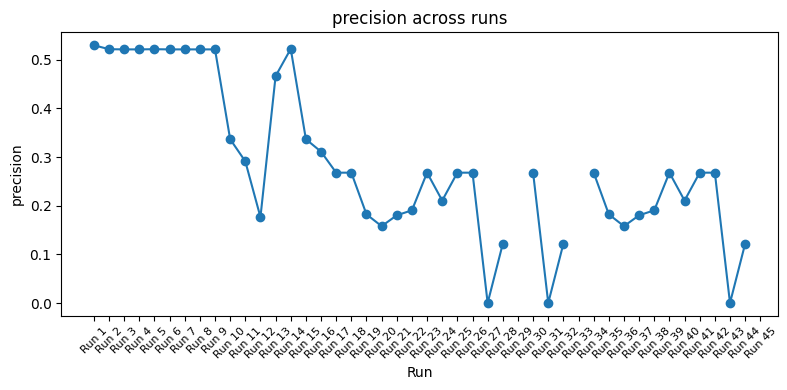

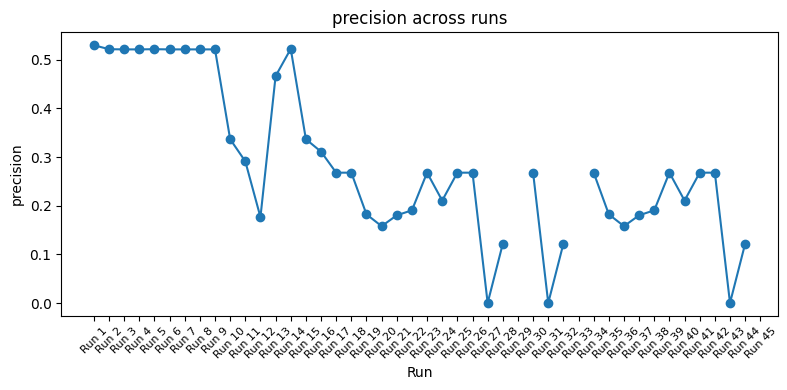

In [4]:
ec.plot_metric_trend("precision", log_df=log_df)


## Tier 2 — financial trend

The cross-step gate — comparable across every step of the sweep, regardless of internal model/label changes.

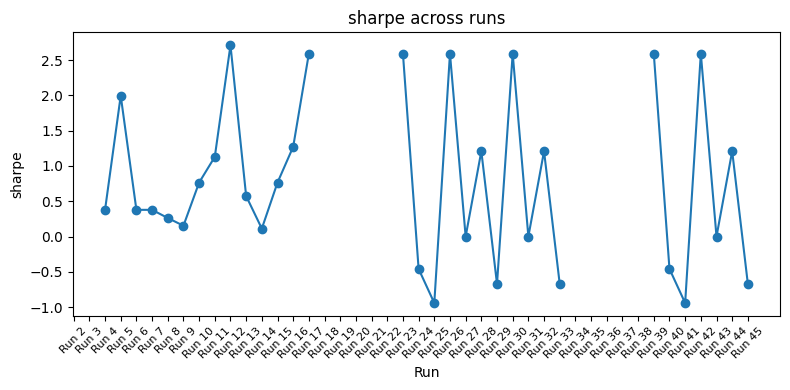

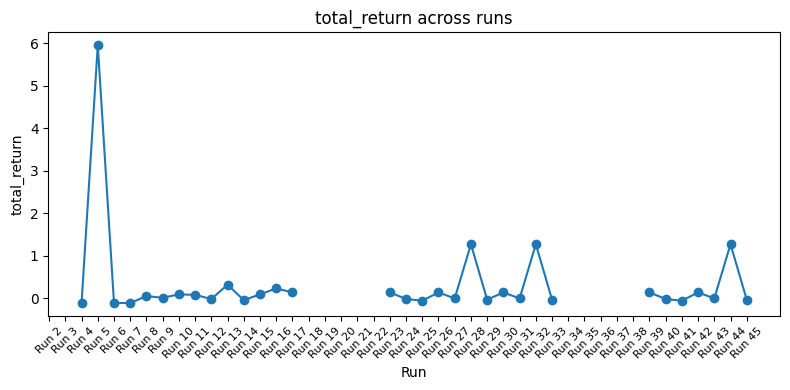

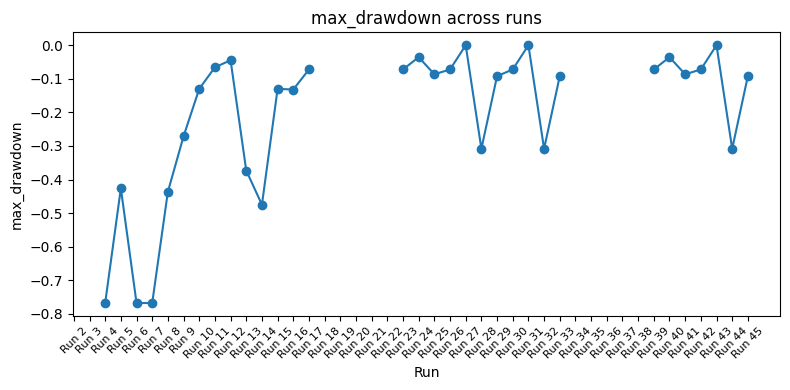

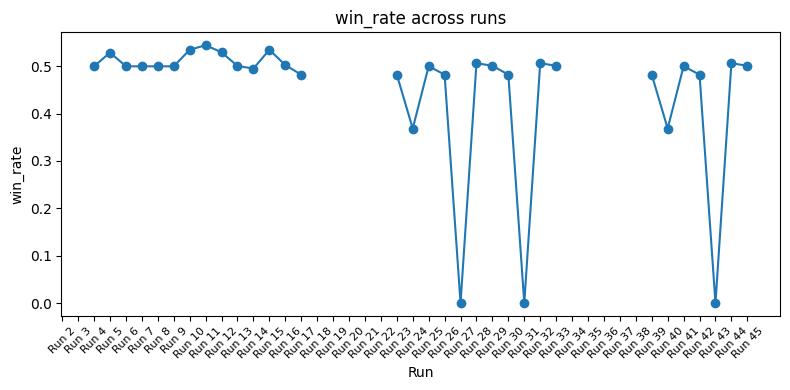

In [5]:
for metric in ["sharpe", "total_return", "max_drawdown", "win_rate"]:
    ec.plot_metric_trend(metric, log_df=log_df)


## Precision vs. Sharpe

Did a Tier 1 (precision) improvement actually pay off at Tier 2 (Sharpe)? A run that
moves up-and-right improved on both; up-and-left means Tier 1 improved but the
financial result got worse — a sign the model is overfitting to the label, not
learning something that survives contact with real trade outcomes.


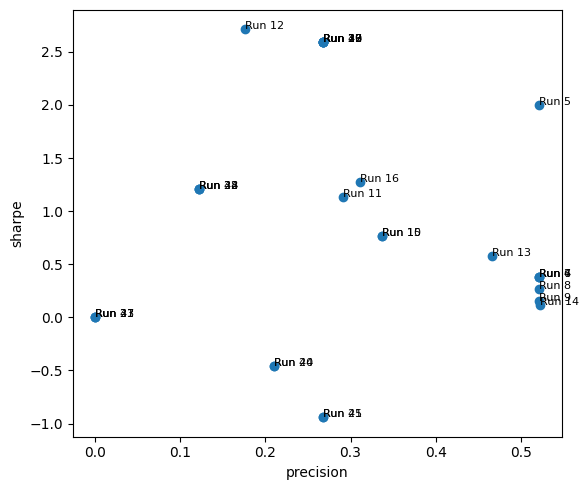

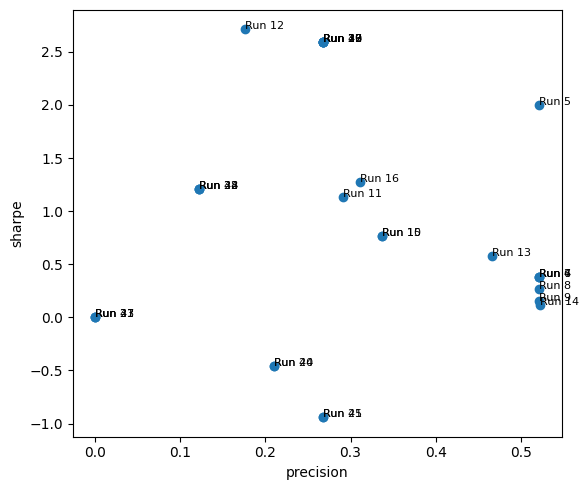

In [6]:
ec.plot_tradeoff("precision", "sharpe", log_df=log_df)


## Best runs so far

Top runs ranked by Sharpe (the primary Tier 2 metric), Max Drawdown as the
hard constraint — a new run only replaces the current champion if Sharpe
improves *and* drawdown doesn't breach the limit.


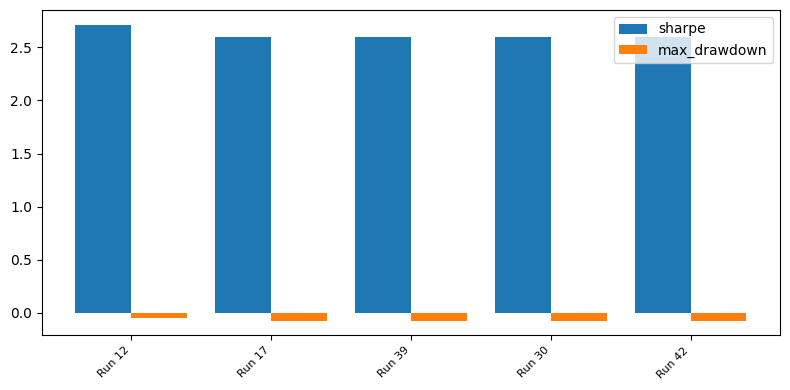

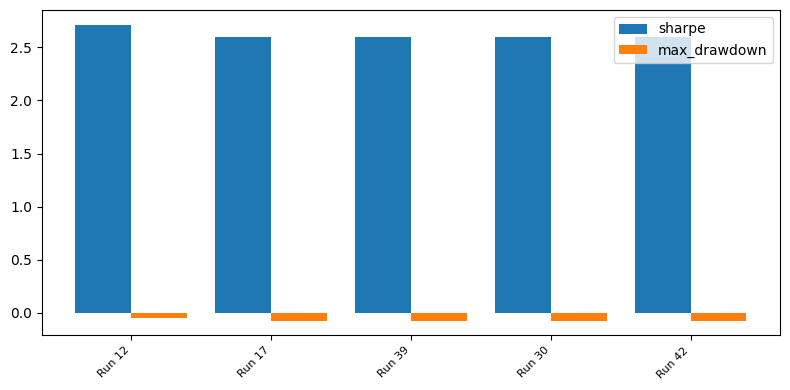

In [7]:
ec.plot_metric_comparison(["sharpe", "max_drawdown"], log_df=log_df, top_n=5)


In [8]:
import sys as _sys
_sys.path.insert(0, os.path.join(PROJECT_ROOT, "scripts"))

## Regularisation, tree-complexity and early stopping — does it close the overfitting gap?

Three follow-up experiments below, run after the sweep above, in response to
code review feedback on the draft report. This one and the next also compute
metrics (payoff stats, outlier robustness, a limit-order execution variant)
that don't fit `experiment_log.csv`'s fixed schema, so they're computed fresh
by re-running the code rather than stored anywhere else — re-run this section
before writing the report from it, rather than trusting stale numbers copied
into prose.

**Hypothesis.** Section [5.5] diagnosed a persistent train/test precision gap
(0.536–0.678). Section [5.6] scoped three untested interventions — regularisation
(`reg_alpha`/`reg_lambda`/`scale_pos_weight`), tree-complexity limits
(`max_depth`/`min_child_weight`/`subsample`), and early stopping on a
validation split — as the direct next step. Does applying them actually
close the gap *and* improve real (test-set) precision, or only make train
precision converge toward test precision without a genuine improvement?


In [9]:
import experiment_overfitting_gap
experiment_overfitting_gap.main()


Training set class balance: 4354 positive / 38094 negative (scale_pos_weight=8.749)

baseline                                       test_precision=0.2679  train_precision=0.9464  gap=0.6785
regularised                                    test_precision=0.1822  train_precision=0.3418  gap=0.1596
tree_complexity                                test_precision=0.1579  train_precision=0.6837  gap=0.5258
regularised+tree_complexity                    test_precision=0.1802  train_precision=0.2039  gap=0.0236
regularised+tree_complexity+early_stopping     test_precision=0.1905  train_precision=0.1949  gap=0.0044

--- Summary (gap vs baseline) ---
baseline                                       gap=0.6785  (+0.0000 vs baseline)
regularised                                    gap=0.1596  (-0.5190 vs baseline)
tree_complexity                                gap=0.5258  (-0.1527 vs baseline)
regularised+tree_complexity                    gap=0.0236  (-0.6549 vs baseline)
regularised+tree_complexity+ear

**Result and interpretation.**

*Tier 1 (precision/gap)*

| Config | Test precision | Train precision | Gap |
|---|---|---|---|
| Baseline (current production) | 0.268 | 0.946 | 0.679 |
| + regularised (reg_alpha/reg_lambda/scale_pos_weight) | 0.182 | 0.342 | 0.160 |
| + tree-complexity (max_depth=3, min_child_weight=5, subsample=0.7) | 0.158 | 0.684 | 0.526 |
| + regularised + tree-complexity | 0.180 | 0.204 | 0.024 |
| + all three + early stopping | 0.191 | 0.195 | **0.004** |

*Tier 2 (backtest)*

| Config | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|
| Baseline (current production) | +14.18% | 48.2% | -7.2% | 2.59 |
| + regularised | +6.85% | 50.0% | -44.7% | 0.30 |
| + tree-complexity | -14.57% | 31.6% | -16.3% | -5.98 |
| + regularised + tree-complexity | +54.77% | 50.4% | -30.3% | 0.78 |
| + all three + early stopping | +96.38% | 50.5% | -34.3% | 1.09 |

The gap closes almost entirely (0.679 → 0.004), but test precision does not
improve in any configuration — it gets slightly worse in every one (0.268 →
0.16–0.19). The gap narrows because regularisation suppresses train precision
down toward the test level, not because the model generalises better.

The Tier 2 numbers look like an improvement at a glance, but are not one
once risk is accounted for. Total return rises sharply as more
interventions stack (+14% → +96%), which on its own could read as
regularisation paying off financially even without a precision gain. But
Sharpe ratio, the risk-adjusted metric, is worse for every regularised
config than the baseline (2.59 vs 0.30–1.09), and max drawdown balloons from
-7.2% to -30% to -45%. Win rate stays flat at ~48–50% throughout, regardless
of how much the gap closes. A large return increase with an unchanged,
near-coin-flip win rate and a much worse Sharpe is the same signature as the
triple-barrier payoff-structure artefact debunked in §5.4 and the outlier
fragility found in the baseline-comparison experiment below — worth the same
outlier-robustness check before trusting it, not yet done here.

This is a negative result for the stated goal. Capacity control alone
does not fix generalisation, and the configs that most successfully close the
gap are the same ones whose apparent return gain looks least trustworthy on
closer inspection. The ceiling looks like it's set by feature/signal quality
or sample size, not model capacity — tested directly in the baseline
comparison below, against a much lower-capacity model.


---
# Stage-by-stage findings

One section per experiment step. Fill in as each step is completed — this
is the raw material for the report's Evaluation chapter.


### Stage 1 — Baseline

**Parameter(s):** `no scale_pos_weight, no triple-barrier, no SUE, no regime filter`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 2 — `scale_pos_weight` (class imbalance)

**Parameter(s):** `scale_pos_weight`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 3 — Triple-barrier labeling

**Parameter(s):** `take_profit / stop_loss / max_holding_days`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 4 — SUE surprise normalization

**Parameter(s):** `normalize_earnings_surprise(method=\"sue\")`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 5 — 200-day SMA regime filter

**Parameter(s):** `apply_regime_filter(sma_window)`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 6 — Meta-labeling

**Parameter(s):** `second-stage classifier config`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_
